In [44]:
# Step 1: Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [45]:
# Step 2: Load the digits dataset
digits = load_digits()
X = digits.data     # flattened 8x8 pixel images (64 features)
y = digits.target   # digit labels (0–9)

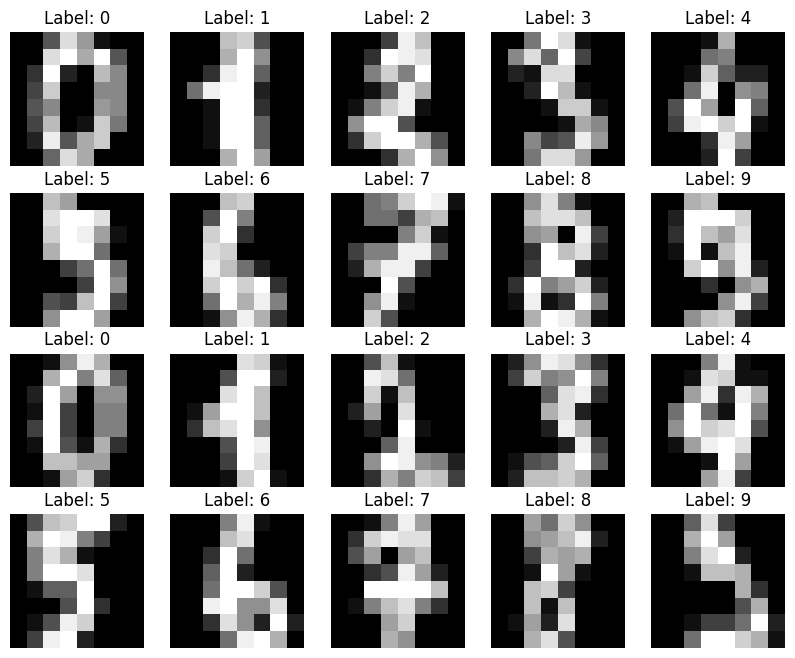

In [46]:
# Plotting 20 random images
fig, axes = plt.subplots(4, 5, figsize=(10, 8))
for i, ax in enumerate(axes.flat):
    ax.imshow(digits.images[i], cmap='gray')
    ax.set_title(f"Label: {digits.target[i]}")
    ax.axis('off')

In [58]:
# Step 3: Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [48]:
# Normalize the data using StandardScaler
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
# Normalize the data using MinMaxScaler
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [59]:
# Step 4: Create and train the Perceptron model
model = Perceptron(max_iter=2000, eta0=0.001, random_state=42)
model.fit(X_train, y_train)

Perceptron(eta0=0.001, max_iter=2000, random_state=42)

In [60]:
# Step 5: Make predictions
y_pred = model.predict(X_test)

In [61]:
# Step 6: Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9259259259259259

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.96      0.98        53
           1       1.00      0.68      0.81        50
           2       0.94      0.98      0.96        47
           3       0.96      0.94      0.95        54
           4       0.95      0.98      0.97        60
           5       0.95      0.95      0.95        66
           6       0.98      0.98      0.98        53
           7       0.96      0.98      0.97        55
           8       0.62      0.95      0.75        43
           9       0.98      0.83      0.90        59

    accuracy                           0.93       540
   macro avg       0.94      0.93      0.92       540
weighted avg       0.94      0.93      0.93       540



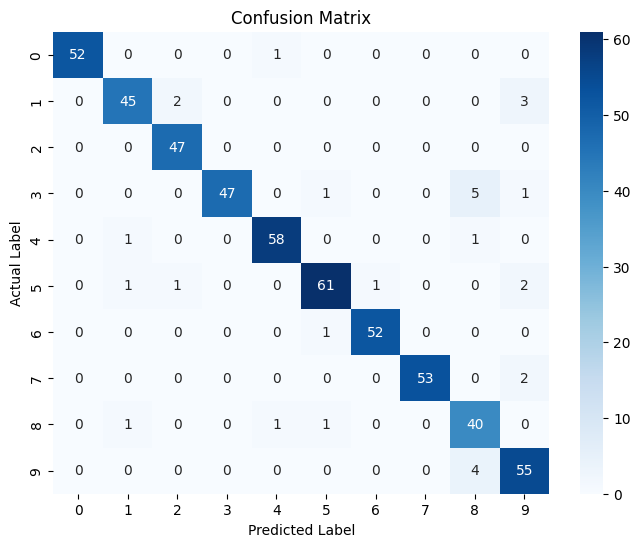

In [13]:
# Step 7: Plot confusion matrix
import seaborn as sns
import pandas as pd

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(pd.DataFrame(cm), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()